# Laboratorijska vježba 2 — šum i uklanjanje šuma

Za ponovljivost pokusa koristi se fiksno sjeme generatora. Uz vizualnu usporedbu prikazan je MSE: manja vrijednost znači vjerniju rekonstrukciju izvorne slike.

In [1]:
from pathlib import Path
import math
import time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

IMG = Path('images')

def show(images, titles, cmaps=None, figsize=(15, 5)):
    """Prikaži jednu ili više slika bez skrivene promjene raspona vrijednosti."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    if cmaps is None:
        cmaps = [None] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def gaussian_noise(shape, mean=0.0, sigma=15.0, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    return rng.normal(mean, sigma, shape).astype(np.float32)

def uniform_noise(shape, a=-25.0, b=25.0, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    return rng.uniform(a, b, shape).astype(np.float32)

def add_noise(img, noise):
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def salt_and_pepper(img, amount=0.10, salt_ratio=0.5, seed=42):
    rng = np.random.default_rng(seed)
    out = img.copy()
    n = int(amount * img.size)
    indices = rng.choice(img.size, size=n, replace=False)
    n_salt = int(salt_ratio * n)
    flat = out.ravel()
    flat[indices[:n_salt]] = 255
    flat[indices[n_salt:]] = 0
    return out

def mse(a, b):
    return float(np.mean((a.astype(np.float32) - b.astype(np.float32)) ** 2))

img = cv.imread(str(IMG / 'barbara.bmp'), cv.IMREAD_GRAYSCALE)
assert img is not None, 'Slika nije pronađena.'

## Zadatak 1 — Gaussov šum

MSE za sliku s Gaussovim šumom: 223.40


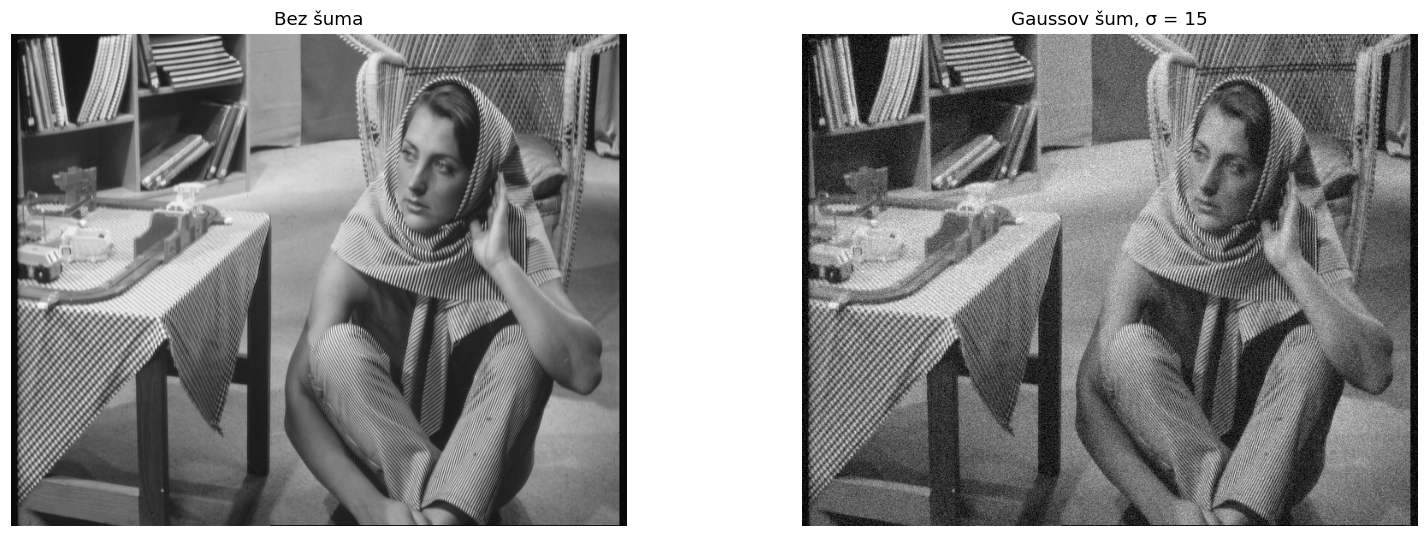

In [2]:
rng = np.random.default_rng(42)
img_gaussian = add_noise(img, gaussian_noise(img.shape, sigma=15, rng=rng))
show([img, img_gaussian], ['Bez šuma', 'Gaussov šum, σ = 15'], ['gray', 'gray'])
print(f'MSE za sliku s Gaussovim šumom: {mse(img, img_gaussian):.2f}')

## Zadatak 2 — histogrami

Za osmobitnu sliku najveći smisleni broj razreda je 256.

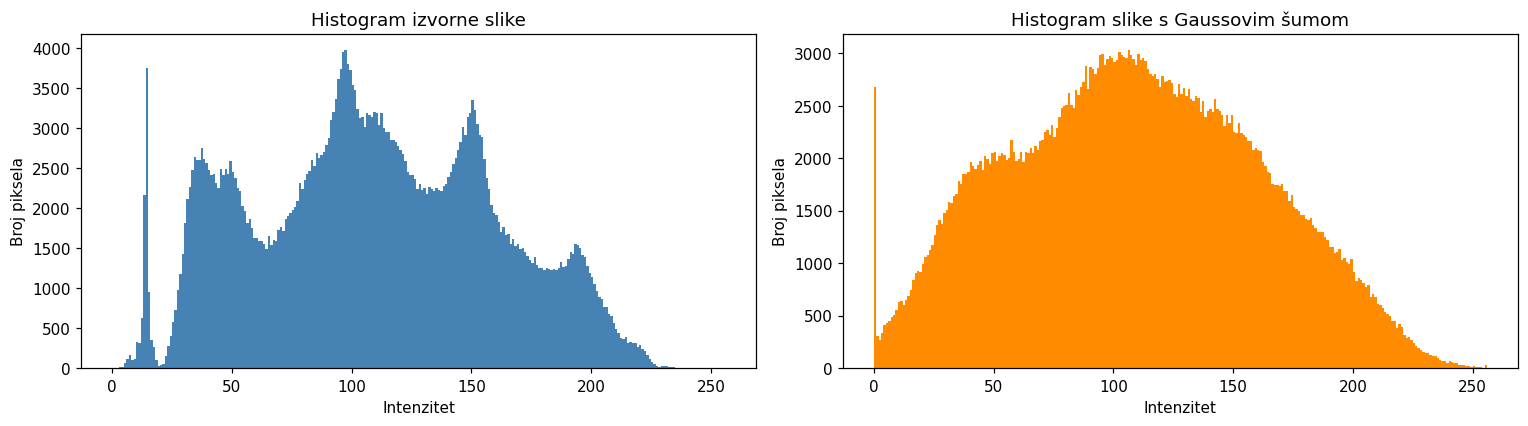

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(img.flatten(), bins=256, range=(0, 256), color='steelblue')
axes[0].set_title('Histogram izvorne slike')
axes[1].hist(img_gaussian.flatten(), bins=256, range=(0, 256), color='darkorange')
axes[1].set_title('Histogram slike s Gaussovim šumom')
for ax in axes:
    ax.set_xlabel('Intenzitet'); ax.set_ylabel('Broj piksela')
plt.tight_layout(); plt.show()

## Zadatak 3 — uniformni šum

MSE Gaussov šum: 223.40
MSE uniformni šum: 207.17


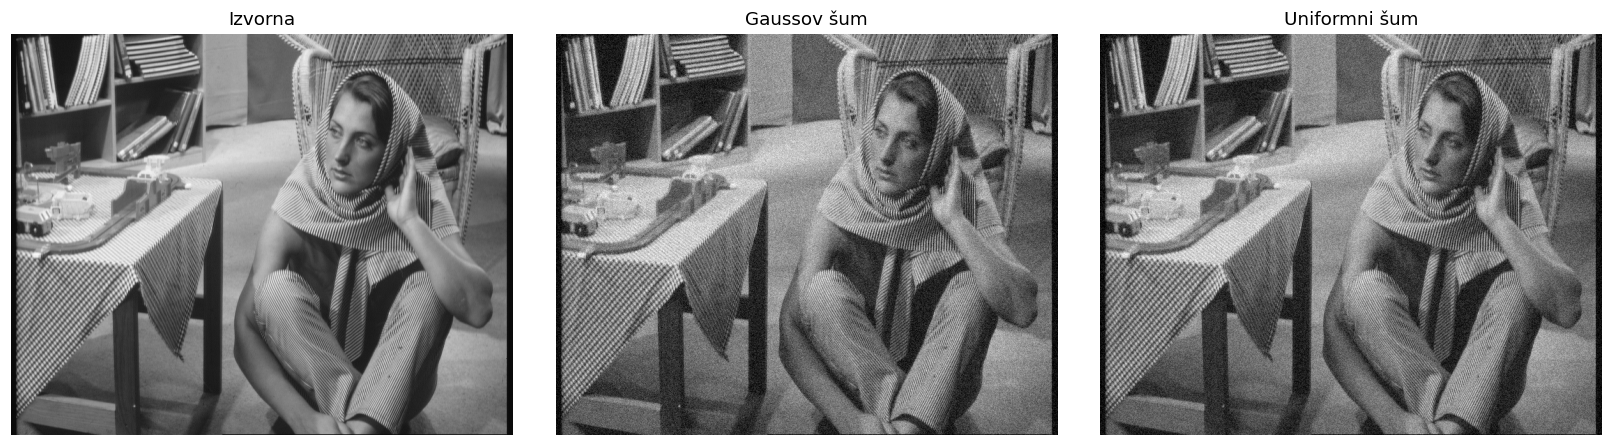

In [4]:
img_uniform = add_noise(
    img, uniform_noise(img.shape, a=-25, b=25, rng=np.random.default_rng(42))
)
show(
    [img, img_gaussian, img_uniform],
    ['Izvorna', 'Gaussov šum', 'Uniformni šum'],
    ['gray'] * 3,
    figsize=(15, 4)
)
print(f'MSE Gaussov šum: {mse(img, img_gaussian):.2f}')
print(f'MSE uniformni šum: {mse(img, img_uniform):.2f}')

## Zadatak 4 — 10 % salt-and-pepper šuma

Ispituju se medijanski filtri 3×3, 5×5 i 7×7 te Gaussovi filtri. Najbolji parametar bira se prema MSE-u, uz vizualnu kontrolu zamućenja.

MSE medijan: {3: 164.82, 5: 266.12, 7: 287.11}
MSE Gaussian: {3: 400.71, 5: 336.68, 7: 328.97}
Odabrani medijanski filtar: 3×3.
Odabrani Gaussov filtar: 7×7.


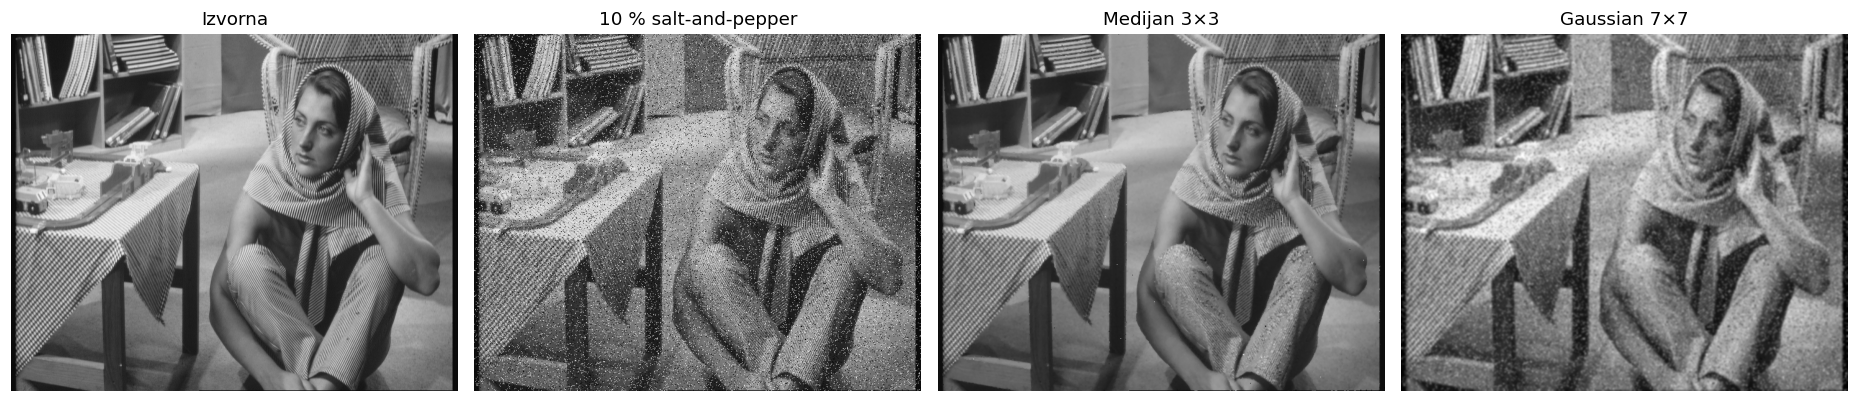

In [5]:
sp_img = salt_and_pepper(img, amount=0.10)
median_candidates = {k: cv.medianBlur(sp_img, k) for k in (3, 5, 7)}
gaussian_candidates = {
    k: cv.GaussianBlur(sp_img, (k, k), sigmaX=0) for k in (3, 5, 7)
}
best_median_k = min(median_candidates, key=lambda k: mse(img, median_candidates[k]))
best_gauss_k = min(gaussian_candidates, key=lambda k: mse(img, gaussian_candidates[k]))

show(
    [img, sp_img, median_candidates[best_median_k], gaussian_candidates[best_gauss_k]],
    ['Izvorna', '10 % salt-and-pepper', f'Medijan {best_median_k}×{best_median_k}',
     f'Gaussian {best_gauss_k}×{best_gauss_k}'],
    ['gray'] * 4,
    figsize=(17, 4)
)
print('MSE medijan:', {k: round(mse(img, v), 2) for k, v in median_candidates.items()})
print('MSE Gaussian:', {k: round(mse(img, v), 2) for k, v in gaussian_candidates.items()})
print(f'Odabrani medijanski filtar: {best_median_k}×{best_median_k}.')
print(f'Odabrani Gaussov filtar: {best_gauss_k}×{best_gauss_k}.')

**Komentar:** Medijanski filtar je prikladniji za impulsni šum jer uklanja ekstremne vrijednosti bez njihova prosječenja sa susjedstvom. Gaussov filtar smanjuje šum, ali jače zamagljuje rubove.

## Zadatak 5 — Gaussov šum σ = 15

Ponovno se ispituju tri veličine jezgre za oba filtra.

MSE medijan: {3: 187.74, 5: 273.04, 7: 294.2}
MSE Gaussian: {3: 124.37, 5: 169.62, 7: 219.22}


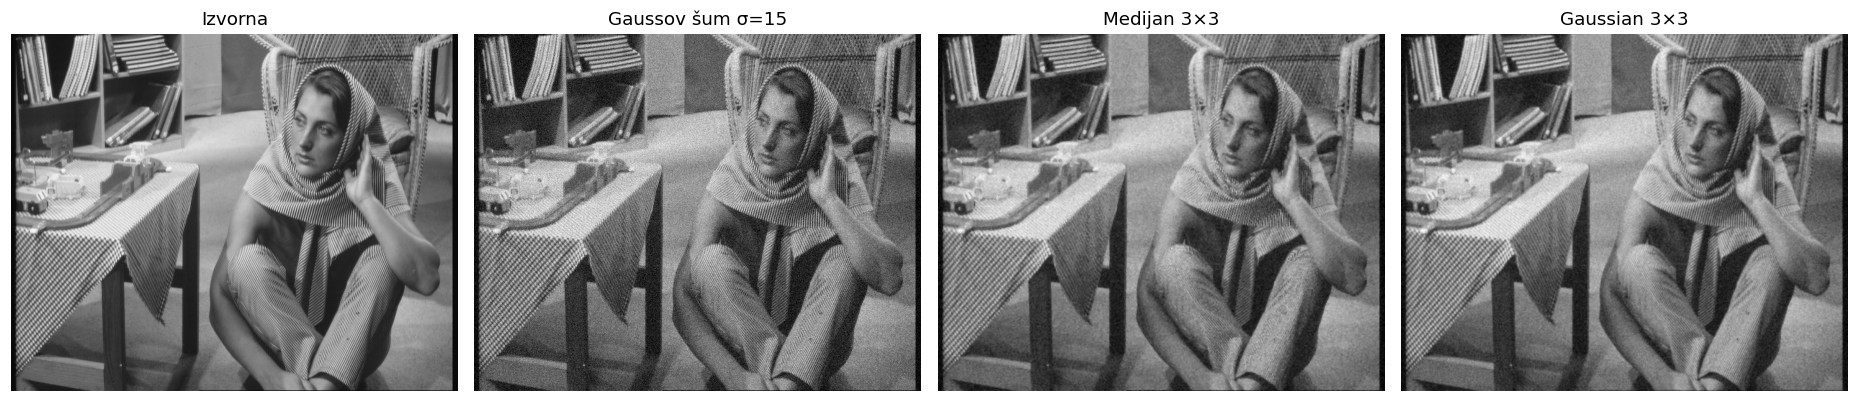

In [6]:
gauss15 = add_noise(img, gaussian_noise(img.shape, sigma=15, rng=np.random.default_rng(7)))
median_g = {k: cv.medianBlur(gauss15, k) for k in (3, 5, 7)}
gaussian_g = {k: cv.GaussianBlur(gauss15, (k, k), sigmaX=0) for k in (3, 5, 7)}
best_median_g = min(median_g, key=lambda k: mse(img, median_g[k]))
best_gaussian_g = min(gaussian_g, key=lambda k: mse(img, gaussian_g[k]))

show(
    [img, gauss15, median_g[best_median_g], gaussian_g[best_gaussian_g]],
    ['Izvorna', 'Gaussov šum σ=15', f'Medijan {best_median_g}×{best_median_g}',
     f'Gaussian {best_gaussian_g}×{best_gaussian_g}'],
    ['gray'] * 4,
    figsize=(17, 4)
)
print('MSE medijan:', {k: round(mse(img, v), 2) for k, v in median_g.items()})
print('MSE Gaussian:', {k: round(mse(img, v), 2) for k, v in gaussian_g.items()})

## Zaključak

Za salt-and-pepper šum medijanski filtar daje bolji kompromis uklanjanja impulsa i očuvanja rubova. Za aditivni Gaussov šum Gaussovo zaglađivanje u pravilu postiže niži MSE, dok prevelika jezgra uklanja detalje.